# Introduction
This notebook performs statistical analysis of the data from the NBV experiments

In [1]:
# Load necessary libraries
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Organize Data from Excel
df = pd.read_excel("NBV Results.xlsx", sheet_name="Results")
df['3D Object'] = df['3D Object'].ffill()

# Restructure data: melt to convert groups to rows
df_organized = df.melt(
    id_vars=['3D Object', 'Metric'],
    value_vars=['Control', 'Augmented', 'NBV'],
    var_name='Group',
    value_name='Value'
)

# Set MultiIndex: 3D Object -> Group -> Metric
df_organized = df_organized.set_index(['3D Object', 'Group', 'Metric']).sort_index()

# Example queries:
# Get all RMS values from NBV group
# rms_nbv = df_organized.xs('NBV', level='Group').xs('RMS', level='Metric')


# Get all metrics for a specific 3D object and group
# armadillo_control = df_organized.xs(('Stanford Armadillo', 'Control'))

# Get specific metric for specific object and group
# armadillo_control_rms = df_organized.loc[('Stanford Armadillo', 'Control', 'RMS'), 'Value']

p_vals = []
chi_s = []

## Friedman's test
The Friedman test statistic measures how much the rank sums differ across groups. It is like ANOVA but does works with non-parametric tests . Groups in this case are the Control, Augmented and NBV methods.

$X^2_{F} = \frac{12}{nk(k+1)} \sigma R^2_j - 3n(k+1)$

Where:
   - $n$ is number of blocks(3D Objects)
   - $k$ is number of treatments(methods)
   - $R_j$ sum of ranks for treatments

Below is an example of it's implementation from [this](https://www.youtube.com/watch?v=2moNzzkkZwU) video:
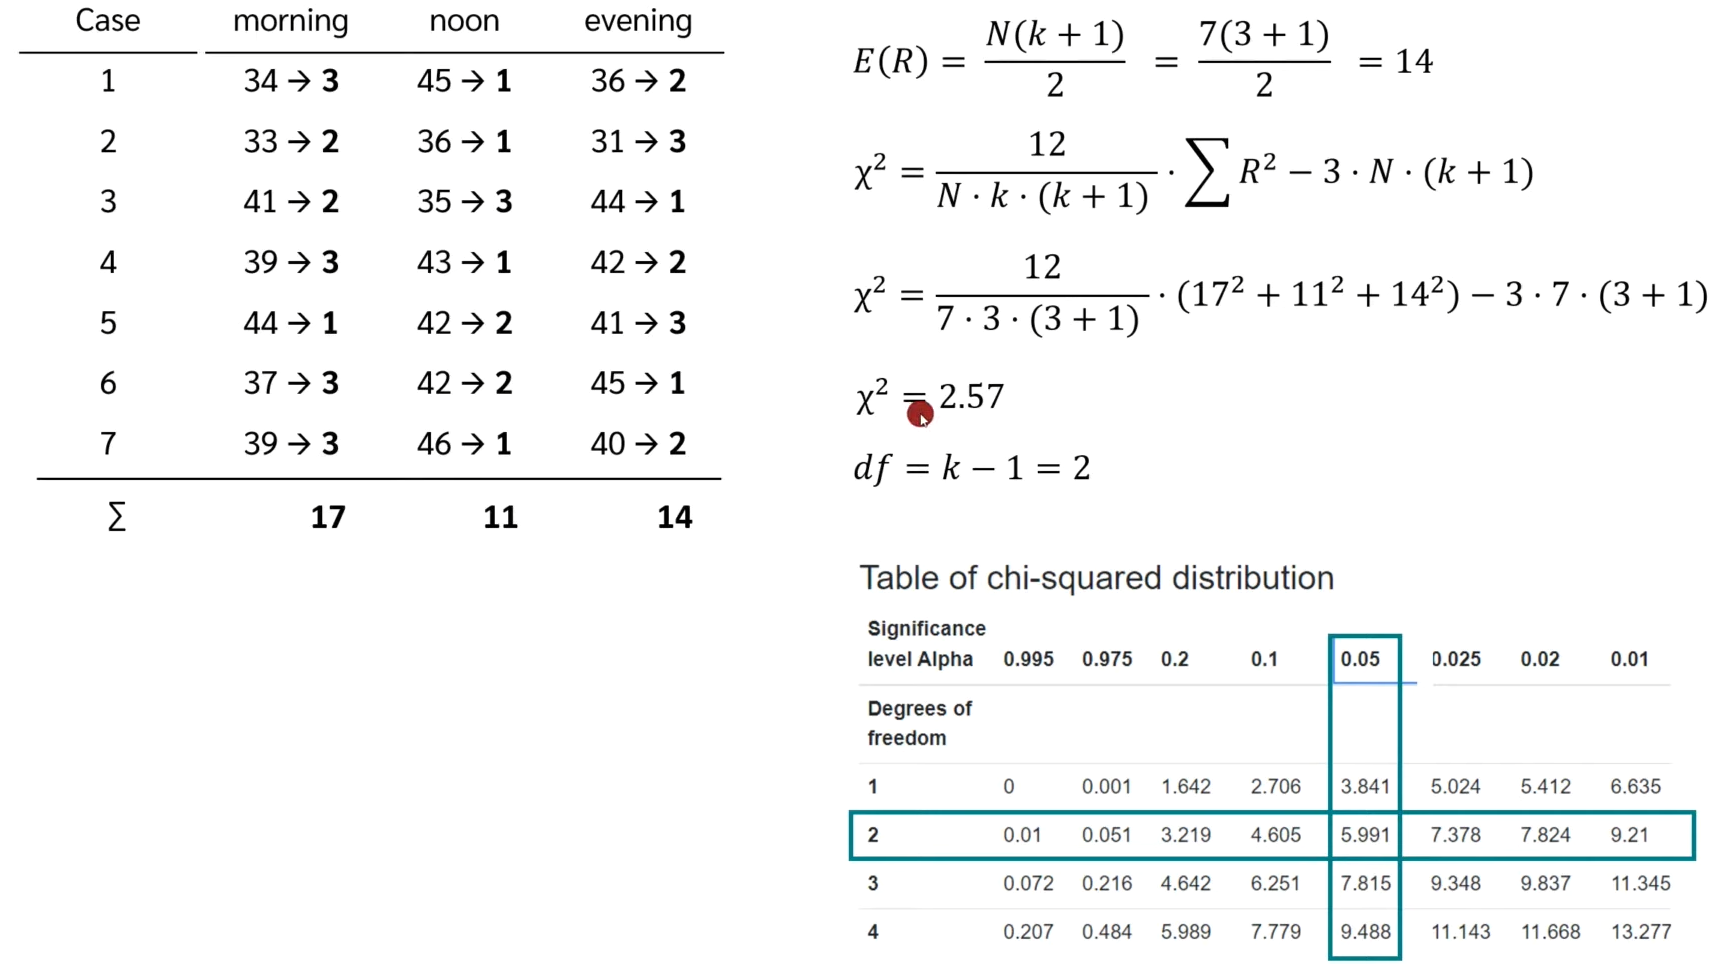

The research question: Is there a difference in the RMS values across the different methods?


## Perform Friedman's tests

### RMS

In [50]:
df_organized.xs('RMS', level='Metric').unstack('Group')['Value']

Group,Augmented,Control,NBV
3D Object,,,
Crashed Car,0.002825,0.003833,0.002911
Generator,0.001504,0.002938,0.001369
Stanford Armadillo,0.001172,0.001691,0.001166
Stanford Bunny,0.001376,0.00206,0.001167
UtahTeapot,0.003729,0.003986,-


In [51]:
rms_ctrl = df_organized.xs('Control', level='Group').xs('RMS', level='Metric').values.flatten()
rms_aug = df_organized.xs('Augmented', level='Group').xs('RMS', level='Metric').values.flatten()
rms_nbv = df_organized.xs('NBV', level='Group').xs('RMS', level='Metric').values.flatten()

result = stats.friedmanchisquare(rms_ctrl[:-1], rms_aug[:-1], rms_nbv[:-1])
print(f" chi-squared statistic is {result.statistic} with a p-value of {result.pvalue}")
chi_s.append(result.statistic)
p_vals.append(result.pvalue)

 chi-squared statistic is 6.5 with a p-value of 0.03877420783172202


We reject the null hypotheses $H_0$. 

There are significant differences in the RMS values across the different methods given the pvalue **0.03877421**

### Hausdorf

In [5]:
df_organized.xs('Hausdorf', level='Metric').unstack('Group')['Value']

Group,Augmented,Control,NBV
3D Object,,,
Crashed Car,0.039384,-0.084341,0.040617
Generator,0.024148,0.03785,-0.017683
Stanford Armadillo,0.073041,0.028501,0.032601
Stanford Bunny,-0.023354,-0.023551,0.016219
UtahTeapot,-0.049875,-0.039293,-


In [48]:
rms_ctrl = df_organized.xs('Control', level='Group').xs('Hausdorf', level='Metric').values.flatten()
rms_aug = df_organized.xs('Augmented', level='Group').xs('Hausdorf', level='Metric').values.flatten()
rms_nbv = df_organized.xs('NBV', level='Group').xs('Hausdorf', level='Metric').values.flatten()



result = stats.friedmanchisquare(rms_ctrl[:-1], rms_aug[:-1], rms_nbv[:-1])
print(f" chi-squared statistic is {result.statistic} with a p-value of {result.pvalue}")
chi_s.append(result.statistic)
p_vals.append(result.pvalue)

 chi-squared statistic is 1.5 with a p-value of 0.4723665527410149


We reject the null hypotheses $H_0$. 

There are significant differences in the RMS values across the different methods given the p-value **0.4723665527410149**

### Accuracy Efficiency

$\frac{\text{RMS}}{\text{# Viewpoints}}$


In [7]:
df_organized.xs('Accuracy Efficiency', level='Metric').unstack('Group')['Value']

Group,Augmented,Control,NBV
3D Object,,,
Crashed Car,7.695267,3.674539,15.614753
Generator,15.8308,8.10399,36.52301
Stanford Armadillo,17.775882,10.951223,32.985882
Stanford Bunny,27.951699,11.558021,77.899821
UtahTeapot,14.898245,5.973287,NaN


In [8]:
accEff_ctrl = df_organized.xs('Control', level='Group').xs('Accuracy Efficiency', level='Metric').values.flatten()
accEff_aug = df_organized.xs('Augmented', level='Group').xs('Accuracy Efficiency', level='Metric').values.flatten()
accEff_nbv = df_organized.xs('NBV', level='Group').xs('Accuracy Efficiency', level='Metric').values.flatten()

result = stats.friedmanchisquare(accEff_ctrl[:-1], accEff_aug[:-1], accEff_nbv[:-1])
print(f" chi-squared statistic is {result.statistic} with a p-value of {result.pvalue}")
chi_s.append(result.statistic)
p_vals.append(result.pvalue)

 chi-squared statistic is 8.0 with a p-value of 0.018315638888734186


We reject the null hypotheses $H_0$. 

There are significant differences in the RMS values across the different methods given the pvalue **0.018315638888734186**

### Quality Efficiency

$\frac{\text{# Points}}{\text{# Viewpoints}}$

In [9]:
row_head = df_organized.index.get_level_values('3D Object').unique().tolist()
col_head = ["Control", "Augmented", "NBV"]


# Extract # Points field
pts_ctrl = df_organized.xs('Control', level='Group').xs('# Points', level='Metric').values.flatten()
pts_aug = df_organized.xs('Augmented', level='Group').xs('# Points', level='Metric').values.flatten()
pts_nbv = df_organized.xs('NBV', level='Group').xs('# Points', level='Metric').values.flatten()

# Extract # Viewpoints
vp_ctrl = df_organized.xs('Control', level='Group').xs('# Viewpoints', level='Metric').values.flatten()
vp_aug = df_organized.xs('Augmented', level='Group').xs('# Viewpoints', level='Metric').values.flatten()
vp_nbv = df_organized.xs('NBV', level='Group').xs('# Viewpoints', level='Metric').values.flatten()

# Find #Points per # Viewpoints
qtyEff_ctrl = pts_ctrl/vp_ctrl
qtyEff_aug = pts_aug/vp_aug
qtyEff_nbv = pts_nbv/vp_nbv

data = list(zip(qtyEff_ctrl, qtyEff_aug, qtyEff_nbv))

pd.DataFrame(data, columns=col_head, index=row_head)

,Control,Augmented,NBV
Crashed Car,597.535211,2025.630435,3620.136364
Generator,2158.690476,3934.523810,8027.900000
Stanford Armadillo,1225.611111,3438.875000,3765.192308
Stanford Bunny,639.619048,1911.230769,2912.727273
UtahTeapot,864.190476,2372.555556,2443.500000


In [10]:
result = stats.friedmanchisquare(qtyEff_ctrl[:-1], qtyEff_aug[:-1], qtyEff_nbv[:-1])
print(f" chi-squared statistic is {result.statistic} with a p-value of {result.pvalue}")
chi_s.append(result.statistic)
p_vals.append(result.pvalue)

 chi-squared statistic is 8.0 with a p-value of 0.018315638888734186


We reject the null hypotheses $H_0$. 

There are significant differences in the RMS values across the different methods given the pvalue **0.018315638888734186**

In [11]:
# Summary of Friedman's Tests

In [12]:
data

[(597.5352112676056, 2025.6304347826087, 3620.1363636363635),
 (2158.690476190476, 3934.5238095238096, 8027.9),
 (1225.611111111111, 3438.875, 3765.1923076923076),
 (639.6190476190476, 1911.2307692307693, 2912.7272727272725),
 (864.1904761904761, 2372.5555555555557, 2443.5)]

In [13]:
rows = ["Chi^2","P-Value"]
cols = [ "RMS", "Hausdorf", "Accuracy Efficiency","Quality Efficiency" ]
data = [chi_s, p_vals]
pd.DataFrame(data, columns=cols, index=rows)

,RMS,Hausdorf,Accuracy Efficiency,Quality Efficiency
Chi^2,6.500000,1.500000,8.000000,8.000000
P-Value,0.038774,0.472367,0.018316,0.018316


# Wilcoxon Signed-Rank Test

The Wilcoxon Signed-Rank test is the non-parametric equivalent of pair t-test

### RMS Metric

In [53]:
## Augmented vs NBV 
result = stats.wilcoxon(list(rms_aug[:-1]), list(rms_nbv[:-1]))
if(result.pvalue < 0.05):
    print(f"We reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")
else:
    print(f"We fail to reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")

    
rms_ctrl = np.array(rms_ctrl, dtype=float)
rms_aug  = np.array(rms_aug, dtype=float)
rms_nbv  =  np.where(rms_nbv == "-", np.nan, rms_nbv).astype(float)

We fail to reject the Null Hyposthesis. 
Chi-squared is 2.0 with a p-value of 0.375


In [15]:
## Control vs NBV 
result = stats.wilcoxon(list(rms_ctrl[:-1]), list(rms_nbv[:-1]))
if(result.pvalue < 0.05):
    print(f"We reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")
else:
    print(f"We fail to reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")


We fail to reject the Null Hyposthesis. 
Chi-squared is 3.0 with a p-value of 0.625


In [16]:
## Control vs AUG 
result = stats.wilcoxon(list(rms_ctrl), list(rms_aug))
if(result.pvalue < 0.05):
    print(f"We reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")
else:
    print(f"We fail to reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")


We fail to reject the Null Hyposthesis. 
Chi-squared is 5.0 with a p-value of 0.625


### Accuracy Efficiency

$\frac{\text{RMS}}{\text{# Viewpoints}}$


In [17]:
## Control vs Augmented 
result = stats.wilcoxon(list(accEff_ctrl), list(accEff_aug))
if(result.pvalue < 0.05):
    print(f"We reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")
else:
    print(f"We fail to reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")


We fail to reject the Null Hyposthesis. 
Chi-squared is 0.0 with a p-value of 0.0625


In [18]:
## Control vs NBV 
result = stats.wilcoxon(list(accEff_nbv[:-1]), list(accEff_ctrl[:-1]))
if(result.pvalue < 0.05):
    print(f"We reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")
else:
    print(f"We fail to reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")


We fail to reject the Null Hyposthesis. 
Chi-squared is 0.0 with a p-value of 0.125


### Quality Efficiency

$\frac{\text{# Points}}{\text{# Viewpoints}}$

In [19]:
## Control vs Augmented 
result = stats.wilcoxon(list(qtyEff_ctrl), list(qtyEff_aug))
if(result.pvalue < 0.05):
    print(f"We reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")
else:
    print(f"We fail to reject the Null Hyposthesis. \nChi-squared is {result.statistic} with a p-value of {result.pvalue}")


We fail to reject the Null Hyposthesis. 
Chi-squared is 0.0 with a p-value of 0.0625


# Summary Plot

Below is a composite chart containing the Accuracy Efficiency and Quality Efficiency for each method 

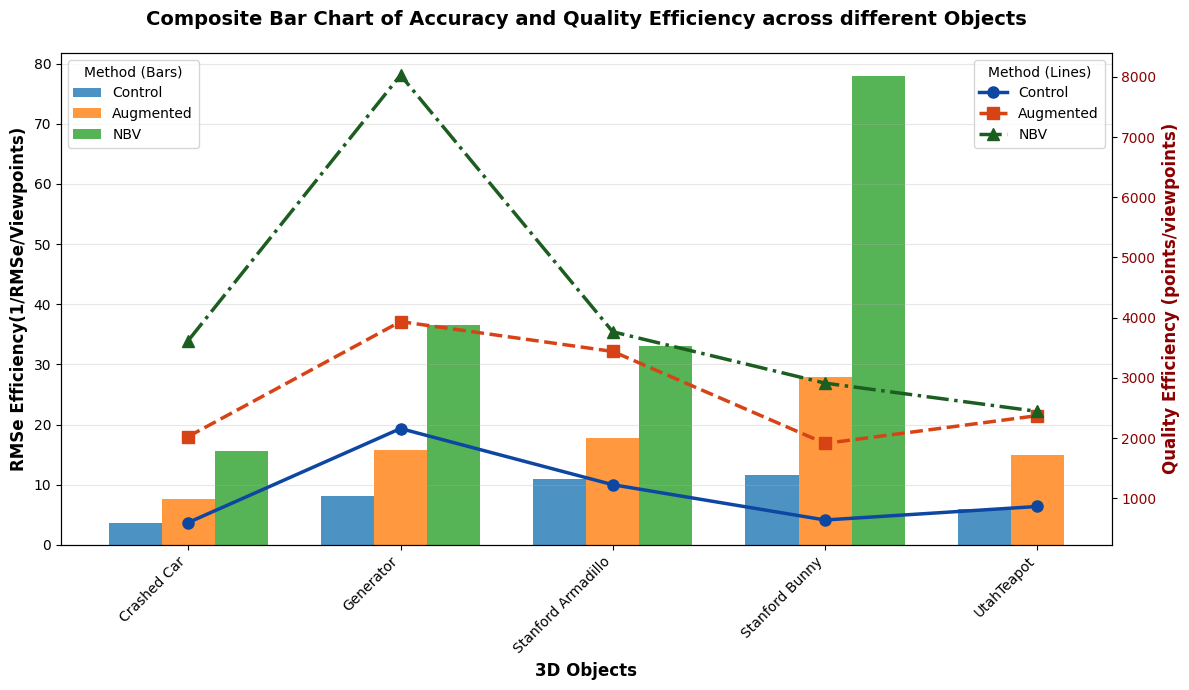

In [30]:
import matplotlib.pyplot as plt
import numpy as np

categories = df_organized.index.get_level_values('3D Object').unique().tolist()
n_objects = len(categories)

# Set up grouped bars positioning
x = np.arange(n_objects)
width = 0.25  # Width of each bar

fig, ax1 = plt.subplots(figsize=(12, 7))

# Create grouped bars on left y-axis
bars1 = ax1.bar(x - width, accEff_ctrl, width, label='Control', 
                color='#1f77b4', alpha=0.8)
bars2 = ax1.bar(x, accEff_aug, width, label='Augmented', 
                color='#ff7f0e', alpha=0.8)
bars3 = ax1.bar(x + width, accEff_nbv, width, label='NBV', 
                color='#2ca02c', alpha=0.8)

# Configure left y-axis (bars)
ax1.set_xlabel('3D Objects', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSe Efficiency(1/RMSe/Viewpoints)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=45, ha='right')
ax1.legend(loc='upper left', title='Method (Bars)')
ax1.grid(True, alpha=0.3, axis='y')

# Create secondary y-axis for line plots
ax2 = ax1.twinx()

# Create 3 line plots on right y-axis
line1 = ax2.plot(x, qtyEff_ctrl, color='#0d47a1', marker='o', 
                 linewidth=2.5, markersize=8, label='Control', linestyle='-')
line2 = ax2.plot(x, qtyEff_aug, color='#d84315', marker='s', 
                 linewidth=2.5, markersize=8, label='Augmented', linestyle='--')
line3 = ax2.plot(x, qtyEff_nbv, color='#1b5e20', marker='^', 
                 linewidth=2.5, markersize=8, label='NBV', linestyle='-.')

# Configure right y-axis (lines)
ax2.set_ylabel('Quality Efficiency (points/viewpoints)', fontsize=12, fontweight='bold', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')
ax2.legend(loc='upper right', title='Method (Lines)')

plt.title('Composite Bar Chart of Accuracy and Quality Efficiency across different Objects', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


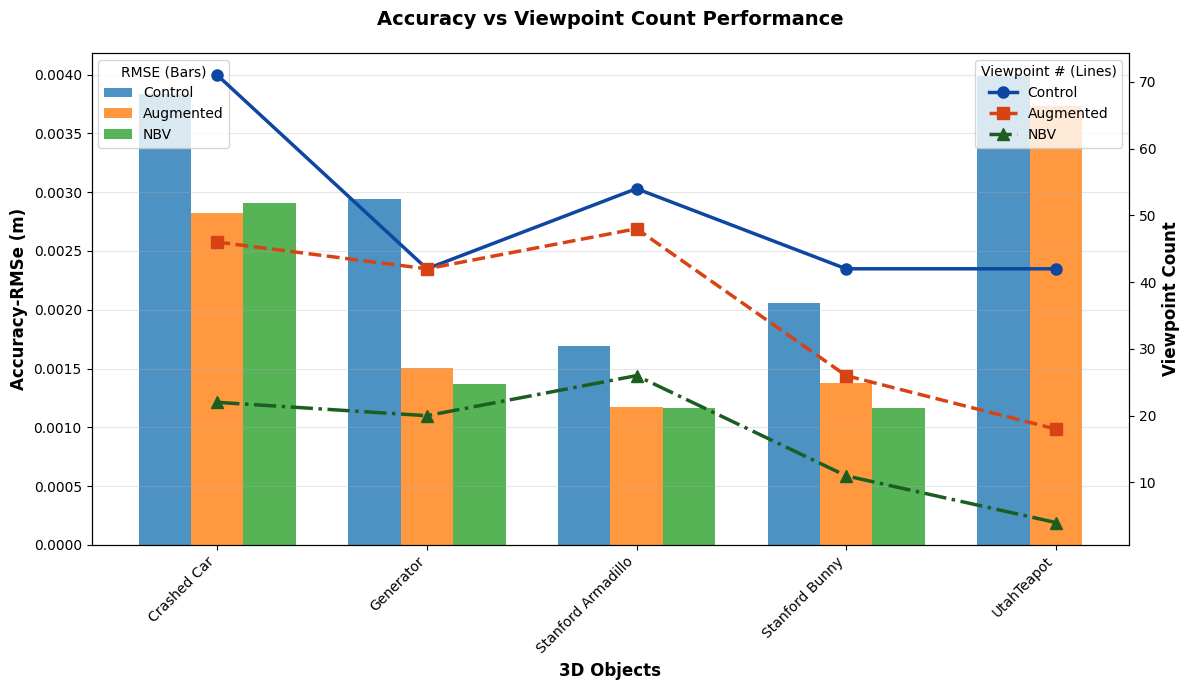

<Figure size 640x480 with 0 Axes>

In [60]:
import matplotlib.pyplot as plt
import numpy as np

categories = df_organized.index.get_level_values('3D Object').unique().tolist()
n_objects = len(categories)

# Set up grouped bars positioning
x = np.arange(n_objects)
width = 0.25  # Width of each bar

fig, ax1 = plt.subplots(figsize=(12, 7))

# Create grouped bars on left y-axis
bars1 = ax1.bar(x - width, rms_ctrl, width, label='Control', 
                color='#1f77b4', alpha=0.8)
bars2 = ax1.bar(x, rms_aug, width, label='Augmented', 
                color='#ff7f0e', alpha=0.8)
bars3 = ax1.bar(x + width, rms_nbv, width, label='NBV', 
                color='#2ca02c', alpha=0.8)

# Configure left y-axis (bars)
ax1.set_xlabel('3D Objects', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy-RMSe (m)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=45, ha='right')
ax1.legend(loc='upper left', title='RMSE (Bars)')
ax1.grid(True, alpha=0.3, axis='y')

# Create secondary y-axis for line plots
ax2 = ax1.twinx()

# Create 3 line plots on right y-axis
line1 = ax2.plot(x, vp_ctrl, color='#0d47a1', marker='o', 
                 linewidth=2.5, markersize=8, label='Control', linestyle='-')
line2 = ax2.plot(x, vp_aug, color='#d84315', marker='s', 
                 linewidth=2.5, markersize=8, label='Augmented', linestyle='--')
line3 = ax2.plot(x, vp_nbv, color='#1b5e20', marker='^', 
                 linewidth=2.5, markersize=8, label='NBV', linestyle='-.')

# Configure right y-axis (lines)
ax2.set_ylabel('Viewpoint Count', fontsize=12, fontweight='bold', color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.legend(loc='upper right', title='Viewpoint # (Lines)')

plt.title('Accuracy vs Viewpoint Count Performance', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

plt.savefig("accuracy_vs_viewpoints.svg", format="svg", bbox_inches="tight")


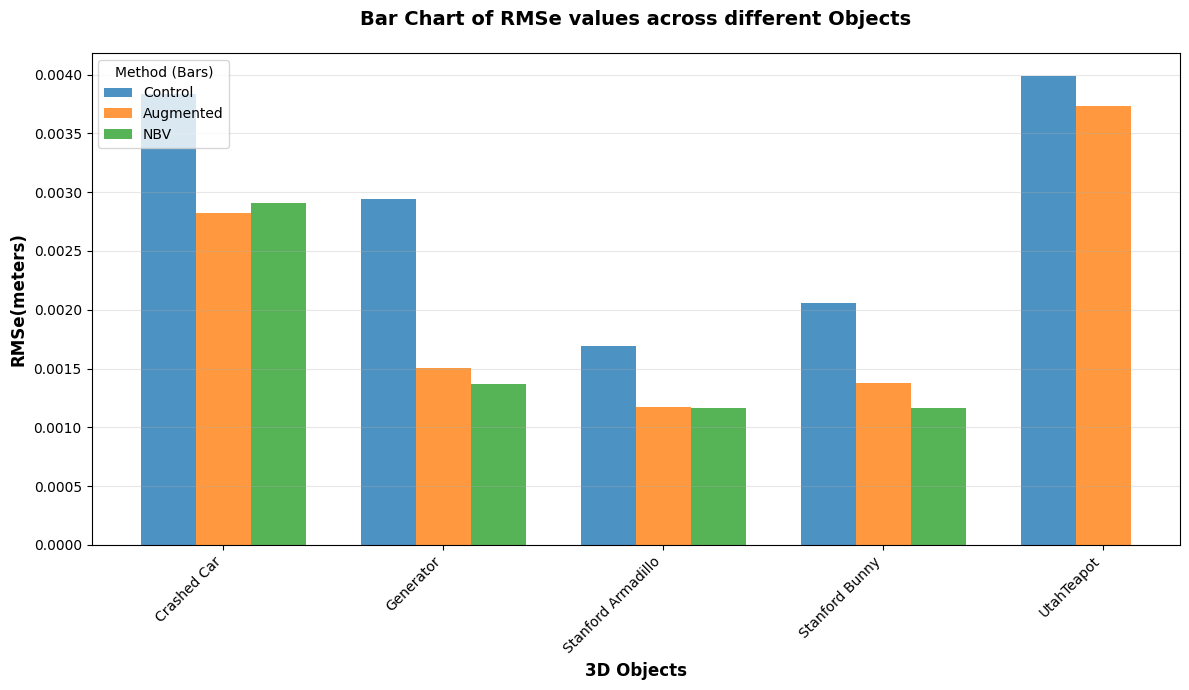

In [46]:
categories = df_organized.index.get_level_values('3D Object').unique().tolist()
n_objects = len(categories)

# Set up grouped bars positioning
x = np.arange(n_objects)
width = 0.25  # Width of each bar

fig, ax1 = plt.subplots(figsize=(12, 7))



# Create grouped bars on left y-axis
bars1 = ax1.bar(x - width, rms_ctrl, width, label='Control', 
                color='#1f77b4', alpha=0.8)
bars2 = ax1.bar(x, rms_aug, width, label='Augmented', 
                color='#ff7f0e', alpha=0.8)
bars3 = ax1.bar(x + width, rms_nbv, width, label='NBV', 
                color='#2ca02c', alpha=0.8)

# Configure left y-axis (bars)
ax1.set_xlabel('3D Objects', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSe(meters)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=45, ha='right')
ax1.legend(loc='upper left', title='Method (Bars)')
ax1.grid(True, alpha=0.3, axis='y')

plt.title('Bar Chart of RMSe values across different Objects', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

$RMSe^{-1}$